In [17]:
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, adfuller, pacf


In [10]:
df = pd.read_csv('../data/raw/ec2_cpu_utilization_24ae8d.csv', parse_dates=['timestamp'])
df = df.set_index('timestamp')

tamanho_treino = int(len(df) * 0.8)
treino = df['value'].iloc[:tamanho_treino].copy()

In [11]:
resultado_adf = adfuller(treino, result_object=False)

print('Teste ADF - série original')
print(f'Estatística do teste: {resultado_adf[0]:.4f}')
print(f'p-valor: {resultado_adf[1]:.6f}')
print('Valores críticos:')
for chave, valor in resultado_adf[4].items():
    print(f'  {chave}: {valor:.4f}')

if resultado_adf[1] < 0.05:
    print('\n→ p-valor < 0.05: Séria estacionária.')
else:
    print('\n→ p-valor >= 0.05: Série NÃO é estacionária.')

Teste ADF - série original
Estatística do teste: -59.8864
p-valor: 0.000000
Valores críticos:
  1%: -3.4324
  5%: -2.8624
  10%: -2.5672

→ p-valor < 0.05: Séria estacionária.


In [12]:
treino_diff = treino.diff().dropna()

resultado_adf_diff = adfuller(treino_diff, result_object=False)

print('Teste ADF — série diferenciada (d=1)')
print(f'Estatística do teste: {resultado_adf_diff[0]:.4f}')
print(f'p-valor: {resultado_adf_diff[1]:.6f}')

if resultado_adf_diff[1] < 0.05:
    print('\n→ Após diferenciação simples, a série é estacionária.')
else:
    print('\n→ Ainda não estacionária — pode ser necessário avaliar diferenciação sazonal também.')

Teste ADF — série diferenciada (d=1)
Estatística do teste: -18.0036
p-valor: 0.000000

→ Após diferenciação simples, a série é estacionária.


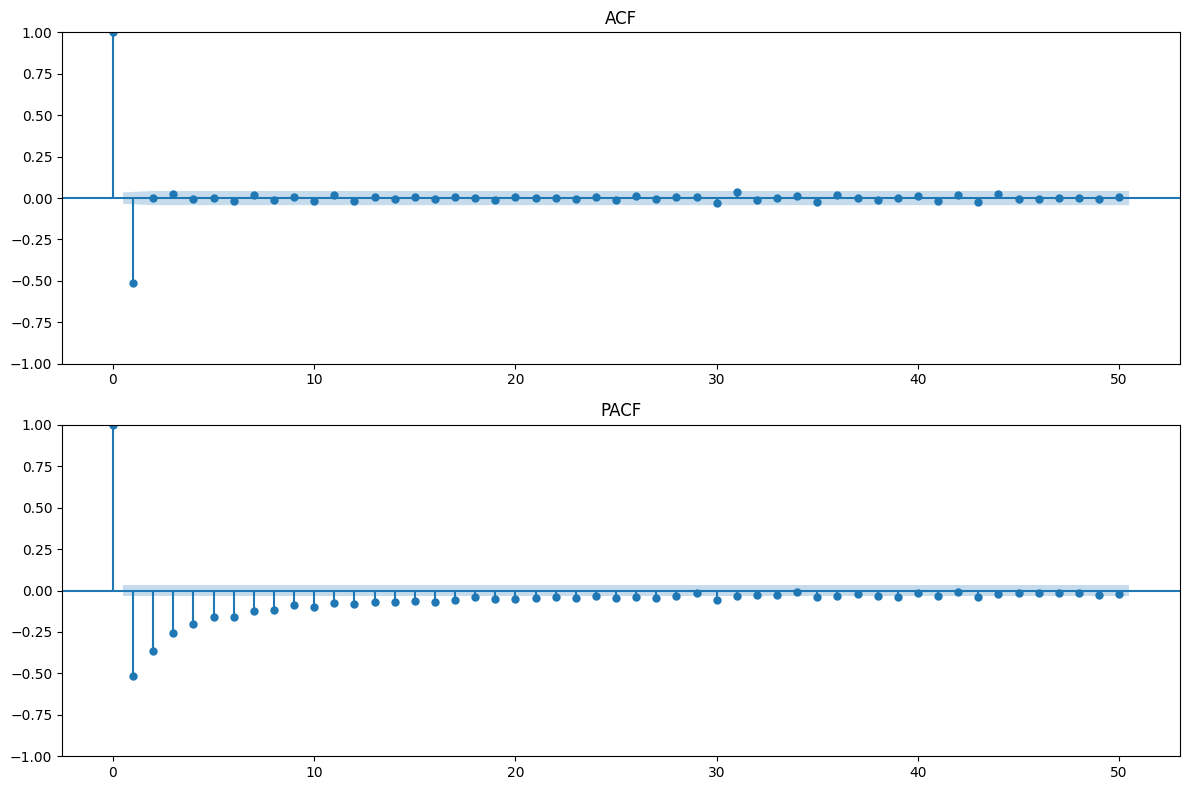

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(treino_diff, lags=50, ax=axes[0])
axes[0].set_title('ACF')
plot_pacf(treino_diff, lags=50, ax=axes[1], method='ywm')
axes[1].set_title('PACF')
plt.tight_layout()
plt.show()

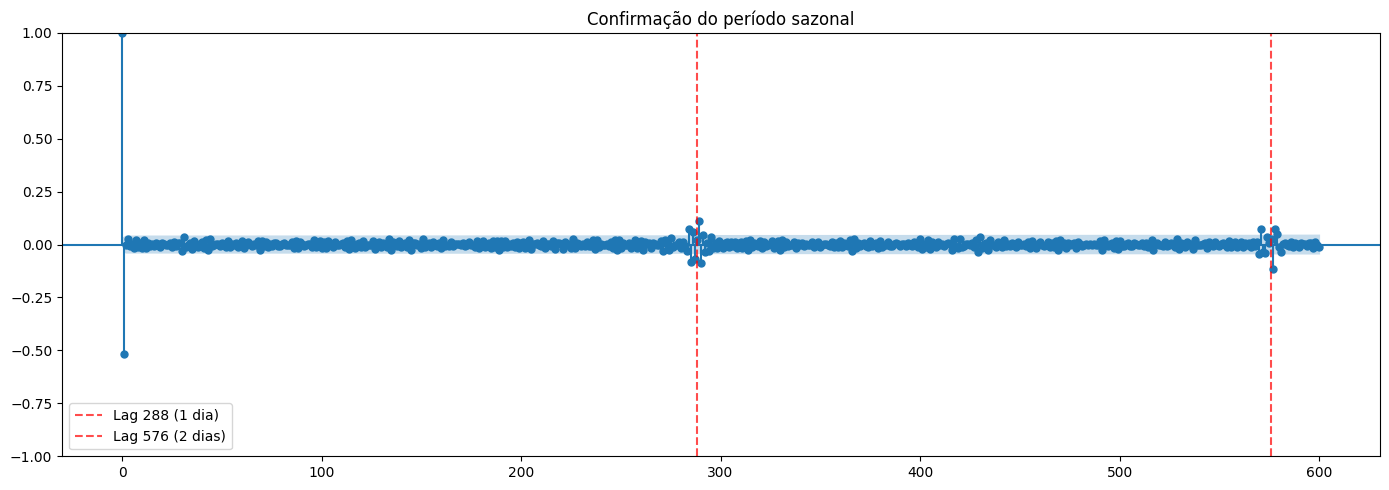

In [14]:
fig, ax = plt.subplots(figsize=(14, 5))
plot_acf(treino_diff, lags=600, ax=ax)
ax.axvline(288, color='red', linestyle='--', alpha=0.7, label='Lag 288 (1 dia)')
ax.axvline(576, color='red', linestyle='--', alpha=0.7, label='Lag 576 (2 dias)')
ax.legend()
ax.set_title('Confirmação do período sazonal')
plt.tight_layout()
plt.show()

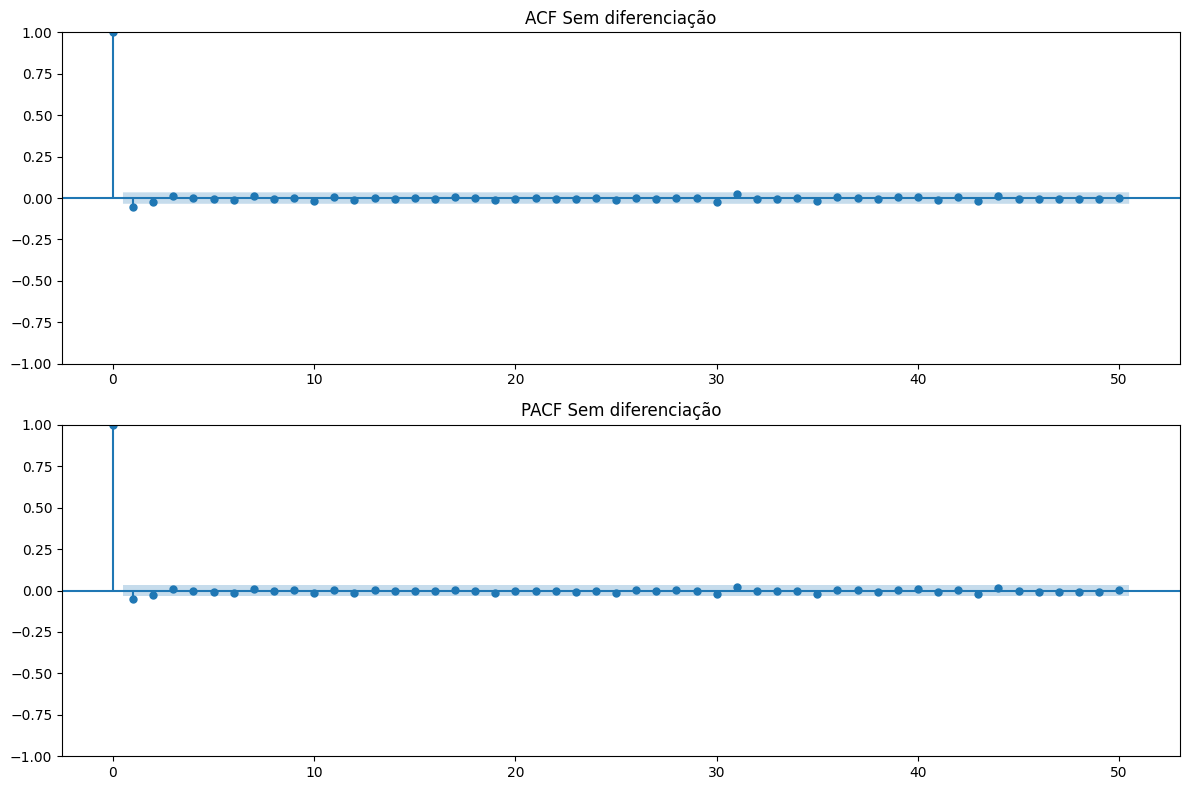

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(treino, lags=50, ax=axes[0])
axes[0].set_title('ACF Sem diferenciação')
plot_pacf(treino, lags=50, ax=axes[1], method='ywm')
axes[1].set_title('PACF Sem diferenciação')
plt.tight_layout()
plt.show()

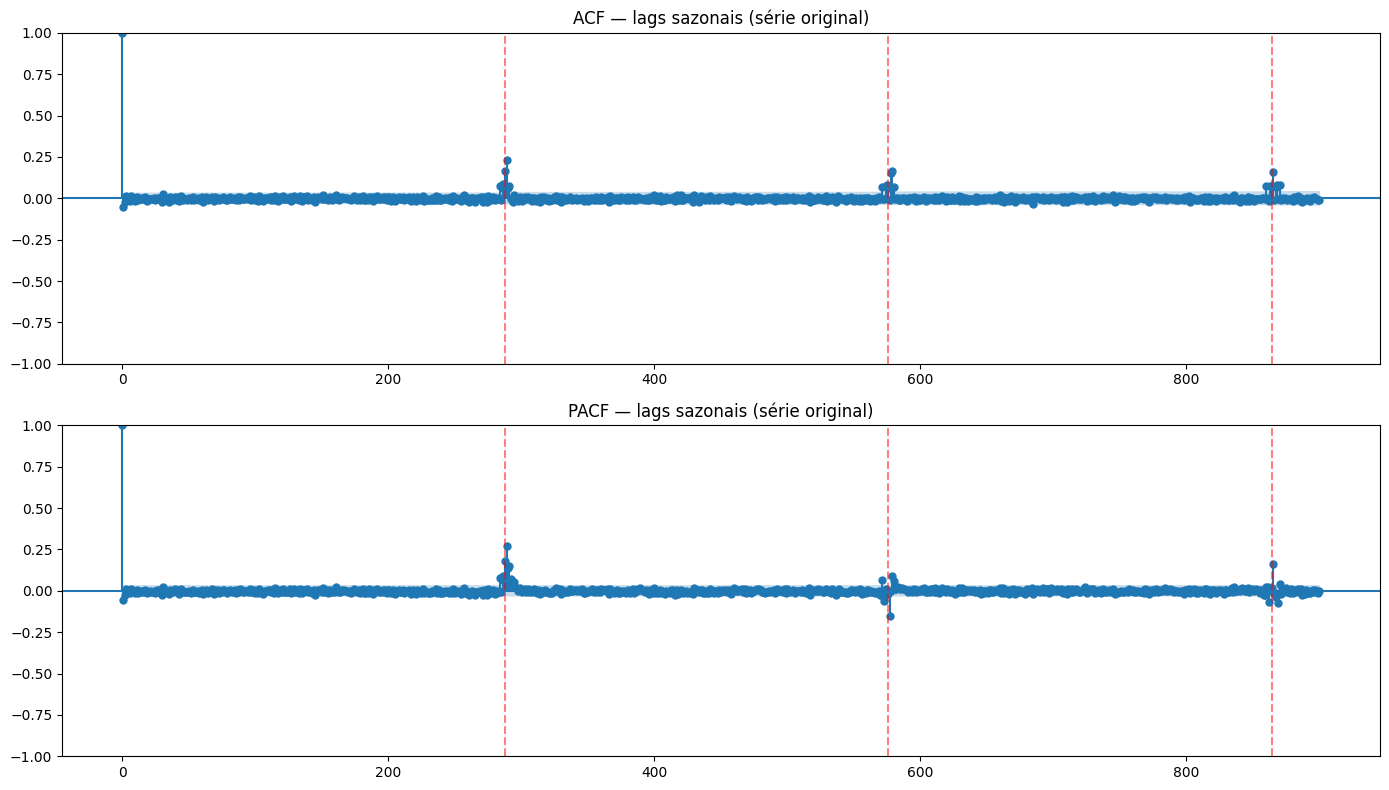

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(treino, lags=900, ax=axes[0])
for lag_sazonal in [288, 576, 864]:
    axes[0].axvline(lag_sazonal, color='red', linestyle='--', alpha=0.5)
axes[0].set_title('ACF Lags sazonais')

plot_pacf(treino, lags=900, ax=axes[1], method='ywm')
for lag_sazonal in [288, 576, 864]:
    axes[1].axvline(lag_sazonal, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('PACF Lags sazonais')

plt.tight_layout()
plt.show()

In [ ]:
valores_acf = acf(treino, nlags=900)
valores_pacf = pacf(treino, nlags=900, method='ywm')

for lag_sazonal in [288, 576, 864]:
    print(f'Lag {lag_sazonal}: ACF = {valores_acf[lag_sazonal]:.4f} | PACF = {valores_pacf[lag_sazonal]:.4f}')